# Proyecto Inventario Salon
## Instalar Dependencias

In [1]:
!pip install -U ultralytics opencv-python-headless pillow gitpython
!pip install -U tensorflow==2.19.0 # o la versión que uses para tflite conversion


In [ ]:
# Fix: Downgrade Pillow to a compatible version
!pip uninstall -y pillow
!pip install pillow==9.5.0

# It's good practice to restart the runtime after downgrading a core library
# You might need to restart the runtime manually after running this cell.

Found existing installation: pillow 12.0.0
Uninstalling pillow-12.0.0:
  Successfully uninstalled pillow-12.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 MB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user


## Repositorio GitHub

In [ ]:
!git clone https://github.com/Gerardo-cursos/objetos_salon.git
# datos quedan en ./objetos_salon/processed


Cloning into 'objetos_salon'...
remote: Enumerating objects: 2794, done.
remote: Counting objects: 100% (358/358), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 2794 (delta 245), reused 163 (delta 163), pack-reused 2436 (from 1)
Receiving objects: 100% (2794/2794), 1.31 GiB | 26.11 MiB/s, done.
Resolving deltas: 100% (542/542), done.
Updating files: 100% (1940/1940), done.


## Subir dataset Yolo

In [2]:
from google.colab import files
uploaded = files.upload()  # selecciona "proyecto_yolo.zip"


Saving proyecto_yolo.zip to proyecto_yolo.zip


In [3]:
import zipfile
with zipfile.ZipFile("proyecto_yolo.zip", 'r') as zip_ref:
    zip_ref.extractall("proyecto_yolo")


In [4]:
import os
os.system("tree proyecto_yolo -L 2")


32512

## Aplicar entorno para entrenar (pytorch etc)

In [5]:
# PARCHES PRE-ENTRENAMIENTO (ejecutar una vez antes de crear el modelo/entrenar)
import os, sys, types, torch
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_START_METHOD"] = "thread"

# stub completo para wandb
_dummy_run = types.SimpleNamespace(log=lambda *a, **k: None, finish=lambda *a, **k: None, sync=lambda *a, **k: None)
class _DummyWandb:
    def __init__(self): self.run = _dummy_run
    def init(self,*a,**k): pass
    def login(self,*a,**k): pass
    def finish(self,*a,**k): pass
    Image = lambda self, x=None: x

sys.modules['wandb'] = _DummyWandb()

# si ultralytics ya cargó callbacks, limpiarlos (no falla si no existen)
try:
    import ultralytics
    from ultralytics.utils import callbacks
    for k in list(callbacks.default_callbacks.keys()):
        if 'wb' in k or 'wandb' in k:
            callbacks.default_callbacks.pop(k, None)
except Exception:
    pass

# permitir tipos seguros en torch.load (si usas checkpoints)
try:
    import dill, ultralytics.nn.modules as um, ultralytics.nn.tasks as ut
    torch.serialization.add_safe_globals([dill._dill._load_type, ut.DetectionModel, um.Conv, um.C2f, um.Bottleneck, um.SPPF, um.Concat, um.C3, getattr(um,"Proto",None)])
except Exception:
    pass


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Entrenar dataset YOLO

In [6]:
!pip install ultralytics torch torchvision torchaudio --quiet
import ultralytics
print("Ultralytics version:", ultralytics.__version__)



Ultralytics version: 8.3.228


In [7]:
# ============================================================
# 🚀 BLOQUE CORREGIDO PARA USAR DATASET EN COLAB
# ============================================================

import os
from ultralytics import YOLO

# --- Ruta base donde subiste tu proyecto
base_path = "/content/proyecto_yolo/dataset"

# --- 1️⃣ Renombrar el archivo data.yaml.txt a data.yaml si es necesario
yaml_txt_path = os.path.join("/content/proyecto_yolo/data.yaml.txt")
yaml_path = os.path.join("/content/proyecto_yolo/data.yaml")

if os.path.exists(yaml_txt_path):
    os.rename(yaml_txt_path, yaml_path)
    print("✅ Renombrado data.yaml.txt → data.yaml")
else:
    print("⚠️ Archivo data.yaml.txt no encontrado, verificando data.yaml existente...")

# --- 2️⃣ Verificar estructura del dataset
expected_folders = [
    os.path.join(base_path, "images/train"),
    os.path.join(base_path, "images/val"),
    os.path.join(base_path, "labels/train"),
    os.path.join(base_path, "labels/val")
]

print("\n🔍 Verificando estructura del dataset...")
for folder in expected_folders:
    print(f"{'✅' if os.path.exists(folder) else '❌'} {folder}")

# --- 3️⃣ Mostrar contenido del YAML (para confirmar rutas)
print("\n📄 Contenido actual de data.yaml:")
!cat /content/proyecto_yolo/dataset/data.yaml


# --- 4️⃣ Entrenar el modelo YOLOv8n
print("\n🚀 Iniciando entrenamiento YOLOv8n...")

model = YOLO("yolov8n.yaml")  # Modelo base (puede usar .pt si quieres transfer learning)
results = model.train(
    data=yaml_path,           # 🔹 Ruta completa y corregida
    epochs=50,
    imgsz=400,
    batch=16,
    name="detect_salon",
)

print("\n✅ Entrenamiento finalizado. Resultados guardados en:")
print(results.save_dir)


✅ Renombrado data.yaml.txt → data.yaml

🔍 Verificando estructura del dataset...
✅ /content/proyecto_yolo/dataset/images/train
✅ /content/proyecto_yolo/dataset/images/val
✅ /content/proyecto_yolo/dataset/labels/train
✅ /content/proyecto_yolo/dataset/labels/val

📄 Contenido actual de data.yaml:
cat: /content/proyecto_yolo/dataset/data.yaml: No such file or directory

🚀 Iniciando entrenamiento YOLOv8n...
Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/proyecto_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0,

## Verificar modelo

In [8]:
import os
from ultralytics import YOLO

# Buscar automáticamente el último modelo entrenado
weights_dir = "/content/runs/detect"
best_weights = None

for root, dirs, files in os.walk(weights_dir):
    for f in files:
        if f == "best.pt":
            best_weights = os.path.join(root, f)

if best_weights:
    print("✅ Modelo encontrado:", best_weights)
    model = YOLO(best_weights)
else:
    raise FileNotFoundError("❌ No se encontró 'best.pt'. Revisa la carpeta /content/runs/detect/")


✅ Modelo encontrado: /content/runs/detect/detect_salon/weights/best.pt


## Cargar imagenes de prueba

In [ ]:
from google.colab import files
uploaded = files.upload()  # selecciona tus imágenes .jpg o .png


Saving Salon_008.jpeg to Salon_008.jpeg


In [ ]:
import glob

# Buscar todas las imágenes subidas
test_images = glob.glob("/content/*.jpg") + glob.glob("/content/*.png") + glob.glob("/content/*.jpeg")

print(f"🖼️ Detectando objetos en {len(test_images)} imágenes...\n")

results = model.predict(
    source=test_images,
    conf=0.2,        # umbral de confianza mínimo
    save=True,       # guarda imágenes con detecciones
    save_txt=True,   # guarda coordenadas en txt (para inventario)
    name="deteccion_final"
)

print("\n✅ Resultados guardados en:")
print(results[0].save_dir)


🖼️ Detectando objetos en 1 imágenes...


0: 320x416 12 sillas, 184.3ms
Speed: 3.6ms preprocess, 184.3ms inference, 8.2ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/deteccion_final
1 label saved to /content/runs/detect/deteccion_final/labels

✅ Resultados guardados en:
/content/runs/detect/deteccion_final


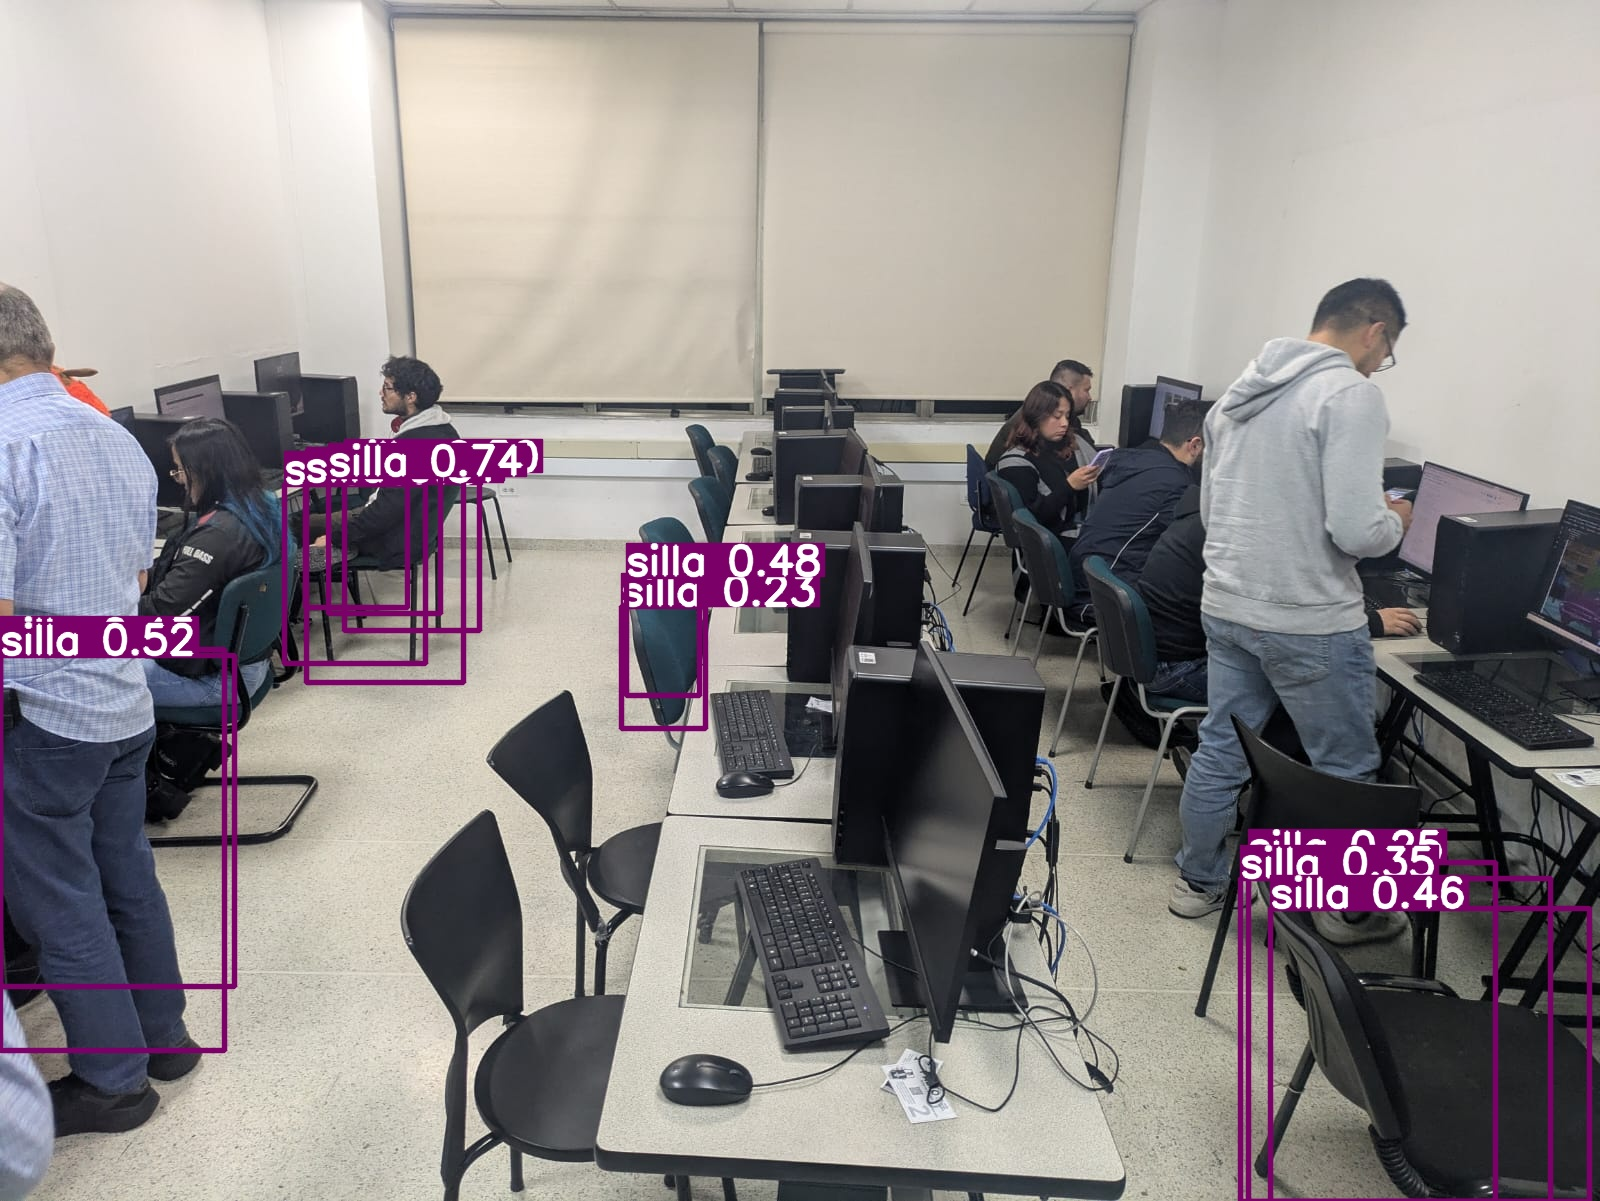

In [ ]:
import IPython.display as display
from PIL import Image

result_path = results[0].save_dir
for img_path in glob.glob(f"{result_path}/*.jpg"):
    display.display(Image.open(img_path))


## Inventario

In [9]:
from collections import Counter

detections = []
for r in results:
    detections.extend(r.names[int(cls)] for cls in r.boxes.cls)

conteo = Counter(detections)
print("\n📦 Inventario detectado:")
for nombre, cantidad in conteo.items():
    print(f"  - {nombre}: {cantidad}")


TypeError: 'DetMetrics' object is not iterable

## Exportacion de modelo

In [10]:
# Exportar el modelo a TFLite (versión ligera)
export_path = model.export(format="tflite")
print("\n✅ Modelo exportado a formato TFLite:")
print(export_path)


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,009,938 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/detect_salon/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 26, 3549) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<=1.19.1', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 2.42s
Prepared 11 packages in 5.92s
Installed 11 packages in 1.50s
 + ai-edge-litert==2.0.3
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnx-graphsurgeon==0.5.8
 + onnx2t

In [21]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/detect_salon/weights/best.pt")

export_path = model.export(
    format="tflite",
    imgsz=320,
    int8=True,
    nms=True
)

print("Exportado a:", export_path)


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
YOLOv8n summary (fused): 72 layers, 3,009,938 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/detect_salon/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.9 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8.yaml'
Fast image access ✅ (ping: 0.0±0.0 ms, read: 965.3±355.7 MB/s, size: 54.0 KB)
Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 4.4Kit/s 0.0s
WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 4 images.

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.74...
ONNX: export success ✅ 1.8s, saved a

## Evaluacion del modelo

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/detect_salon4/weights/best.pt")


In [ ]:
metrics = model.val(data="/content/proyecto_yolo/proyecto/data.yaml")


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1461.8±566.6 MB/s, size: 104.3 KB)
val: Scanning /content/proyecto_yolo/proyecto/dataset/labels/val.cache... 21 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21/21 4.9Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.1s/it 4.1s
                   all         21        860      0.301      0.113     0.0841     0.0282
                 mouse         21         97          0          0          0          0
                 silla         21        162      0.296      0.309      0.236     0.0843
                  mesa         20        112      0.101     0.0893     0.0309    0.00774
               teclado         21        115          1          0     0.0409    0.00499
                   cpu         21        199      0.249      0.206      0.126     0.0412
              pantall

In [ ]:
print("📊 Resultados generales del modelo:")
print(f"Precision: {metrics.box.map50:.4f}")
print(f"Recall: {metrics.box.map:.4f}")
print(f"mAP@50: {metrics.box.map50:.4f}")
print(f"mAP@50-95: {metrics.box.map75:.4f}")


📊 Resultados generales del modelo:
Precision: 0.0841
Recall: 0.0282
mAP@50: 0.0841
mAP@50-95: 0.0137


# Exportar modelo

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/detect_salon/weights/best.pt")
print("Modelo cargado correctamente")


Modelo cargado correctamente


In [ ]:
export_path = model.export(format="tflite")
export_path


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,009,938 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/detect_salon/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 26, 3549) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<=1.19.1', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 2.81s
Prepared 11 packages in 5.29s
Installed 11 packages in 556ms
 + ai-edge-litert==2.0.3
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.19.1
 + onnx-graphsurgeon==0.5.8
 + onnx2t

'/content/runs/detect/detect_salon/weights/best_saved_model/best_float32.tflite'

In [ ]:
export_path_int8 = model.export(format="tflite", int8=True)
export_path_int8


Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
YOLOv8n summary (fused): 72 layers, 3,009,938 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/detect_salon/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 26, 3549) (5.9 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: collecting INT8 calibration images from 'data=coco8.yaml'

WARNING ⚠️ Dataset 'coco8.yaml' images not found, missing path '/content/datasets/coco8/images/val'
Unzipping /content/datasets/coco8.zip to /content/datasets/coco8...: 100% ━━━━━━━━━━━━ 25/25 1.4Kfiles/s 0.0s
Dataset download success ✅ (0.4s), saved to /content/datasets

Fast image access ✅ (ping: 0.0±0.0 ms, read: 942.4±122.2 MB/s, size: 54.0 KB)
Scanning /content/datasets/coco8/labels/val... 4 images, 0 backgrounds, 

'/content/runs/detect/detect_salon/weights/best_saved_model/best_int8.tflite'

In [23]:
import onnx
model = onnx.load("/content/runs/detect/detect_salon/weights/best.onnx")
print(model.graph.output)


[name: "output0"
type {
  tensor_type {
    elem_type: 1
    shape {
      dim {
        dim_value: 1
      }
      dim {
        dim_value: 300
      }
      dim {
        dim_value: 6
      }
    }
  }
}
]
